# EBPP Final Project: Hierarchical Bayesian Analysis of Player Impact

## Case Study: Nikola Mirotić & FC Barcelona Basketball — 2021/2022 Season

**Goal.** Estimate whether FC Barcelona generated better shots when Nikola Mirotić was on court, and compare a clean non-hierarchical logistic baseline against a hierarchical logistic model.

**Storyline.**

1. Data loading and feature engineering
2. Exploratory data analysis
3. Bayesian baseline: Beta-Binomial ON vs OFF
4. Non-hierarchical baseline: Logistic Regressor by scenario
5. Hierarchical model: Hierarchical Logistic Regressor with partial pooling
6. Model comparison using WAIC and LOO-CV

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.special as sp
from scipy.stats import beta

# if error or warning about g++, o conda prompt:
# conda install -c conda-forge gxx_linux-64
# or
# conda install -c conda-forge m2w64-toolchain

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Data Loading and Feature Engineering

In this project, we will be using data obtained from the GitHub of Miquel Villaró (@mikivillaro10). In the downloaded dataset, we have available play-by-play attacking data of the whole season 2021-2022 of the FC Barcelona basketball team.

We are specially interested on the columns indicating the players that are on court (`point_guard`, `shooting_guard`, `small_forward`, `power_forward`, `center`), the one indicating if there was a good shot at the end of the play (`good_shot`), the `clutch` boolean column that indicates whether we are on a decisive moment of the match and the `court` one that indicates if the game was taking place in a local, visitant or neutral enviroment.

In [2]:
df = pd.read_csv("data/Data_AllSeason.csv")

headers = [
    'play_id', 'point_guard', 'shooting_guard', 'small_forward', 'power_forward', 'center',
    'points_difference', 'play_type', 'good_shot', 'points', 'quarter', 'clutch',
    'opponent', 'court', 'competition'
]
df.columns = headers
display(df)

,play_id,point_guard,shooting_guard,small_forward,power_forward,center,points_difference,play_type,good_shot,points,quarter,clutch,opponent,court,competition
0,1,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,0,2,1,2,1,0,Alba Berlin,Local,Eurolliga
1,2,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,2,2,1,3,1,0,Alba Berlin,Local,Eurolliga
2,3,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,2,1,0,Alba Berlin,Local,Eurolliga
3,4,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,5,2,1,3,1,0,Alba Berlin,Local,Eurolliga
4,5,Calathes,Higgins,Hayes-Davis,Mirotic,Davies,8,4,1,0,1,0,Alba Berlin,Local,Eurolliga
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3637,3638,Calathes,Higgins,Abrines,Mirotic,Sanli,7,4,1,2,4,0,Olympiacos,Neutral,F4
3638,3639,Calathes,Higgins,Abrines,Mirotic,Sanli,6,4,0,0,4,1,Olympiacos,Neutral,F4
3639,3640,Calathes,Higgins,Abrines,Mirotic,Sanli,5,2,1,2,4,1,Olympiacos,Neutral,F4
3640,3641,Calathes,Higgins,Abrines,Mirotic,Sanli,7,1,1,2,4,0,Olympiacos,Neutral,F4


To complement this dataframe taking into account our objective, we add a feature called `has_mirotic`. This new column will serve us as an indicator of whether Mirotić is present or not in the court.

In [3]:
player_cols = ['point_guard', 'shooting_guard', 'small_forward', 'power_forward', 'center']
df['has_mirotic'] = df[player_cols].eq('Mirotic').any(axis=1).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Total plays: {len(df)}")
print(f"Mirotić ON plays: {df['has_mirotic'].sum()}")
print(f"Mirotić OFF plays: {(1 - df['has_mirotic']).sum()}")

Dataset shape: (3642, 16)
Total plays: 3642
Mirotić ON plays: 2132
Mirotić OFF plays: 1510


To continue, we encode categorical variables into indexing matrices for hierarchy mapping. We will use this later on the Logistic Regressor models. The categories will be defined as a combination of court enviroment (local, visitant or neutral) and the indicator of clutch time:

In [4]:
# Scenario: court environment x clutch indicator
df['strat_group'] = df['court'].astype(str) + "_" + df['clutch'].astype(str)

cat = pd.Categorical(df['strat_group'])
group_idx = cat.codes
group_names = cat.categories.to_numpy()
num_groups = len(group_names)
group_mapping = group_idx

# Model arrays
y_obs = df['good_shot'].astype(int).values
has_mirotic_idx = df['has_mirotic'].astype(int).values

print(f"Number of scenario groups: {num_groups}")

for idx, name in enumerate(group_names):
    print(f"Index {idx}: {name} | N={(group_idx == idx).sum()}")

Number of scenario groups: 6
Index 0: Local_0 | N=1638
Index 1: Local_1 | N=193
Index 2: Neutral_0 | N=88
Index 3: Neutral_1 | N=94
Index 4: Visitant_0 | N=1515
Index 5: Visitant_1 | N=114


## 2. Exploratory Analysis of `good_shot`

We first inspect the raw proportion of good shots with Mirotić on and off court. This is not causal evidence, but it gives a useful first signal.

In [5]:
df_mirotic = df[df['has_mirotic'] == 1].copy()
df_no_mirotic = df[df['has_mirotic'] == 0].copy()

summary = pd.DataFrame({
    'Context': ['Mirotić ON', 'Mirotić OFF', 'Overall'],
    'N': [len(df_mirotic), len(df_no_mirotic), len(df)],
    'Good shots': [df_mirotic['good_shot'].sum(), df_no_mirotic['good_shot'].sum(), df['good_shot'].sum()],
    'Good-shot rate': [df_mirotic['good_shot'].mean(), df_no_mirotic['good_shot'].mean(), df['good_shot'].mean()]
})
summary


,Context,N,Good shots,Good-shot rate
0,Mirotić ON,2132,1417,0.664634
1,Mirotić OFF,1510,910,0.602649
2,Overall,3642,2327,0.638935


We do the same for each of the categories we defined before so that we can get an idea of the results expected.

In [6]:
scenario_summary = (
    df.groupby(['strat_group', 'has_mirotic'])['good_shot']
      .agg(['count', 'sum', 'mean'])
      .reset_index()
      .rename(columns={'count': 'N', 'sum': 'Good shots', 'mean': 'Good-shot rate'})
)
scenario_summary


,strat_group,has_mirotic,N,Good shots,Good-shot rate
0,Local_0,0,753,457,0.606906
1,Local_0,1,885,608,0.687006
2,Local_1,0,34,19,0.558824
3,Local_1,1,159,119,0.748428
4,Neutral_0,0,38,23,0.605263
5,Neutral_0,1,50,38,0.760000
6,Neutral_1,0,17,11,0.647059
7,Neutral_1,1,77,51,0.662338
8,Visitant_0,0,645,390,0.604651
9,Visitant_0,1,870,553,0.635632


## 3. Bayesian Baseline: Beta-Binomial ON vs OFF

This block answers the simplest version of the question:

> Is the overall good-shot rate higher when Mirotić is on court?

We will use this model as a simple baseline to get an idea of the overall importance of Mirotić in the team.

### Model choice

We have the following Beta-Binomial model for each case:
- Mirotic Case:
$$
Y_M \mid \pi_M \sim \mathrm{Binomial}(2132,\pi_M),
\qquad
\pi_M \sim \mathrm{Beta}(\alpha,\beta).
$$

- No Mirotic Case:
$$
Y_N \mid \pi_N \sim \mathrm{Binomial}(1510,\pi_N),
\qquad
\pi_N \sim \mathrm{Beta}(\alpha,\beta).
$$
Where $Y_M$ and $Y_N$ are the observed number of successes, $\pi_M$ and $\pi_N$ are the unknown true population proportion, and $n_M=2132$ and $n_D=1510$ are the total sample size for the Mirotic and No Mirotic case respectively.

### Prior definition

We chose an **Empirical Bayes** prior based on the team's overall success rate ($p = 0.63$) seen before. We set the prior strength to $N = 70$ (about 3-4% of our total data), which provides a stable baseline without overwhelming the actual evidence from the data. We apply the same prior to both cases to ensure a fair comparison.

The resulting prior is the following:

Prior: Beta(44.73, 25.27)


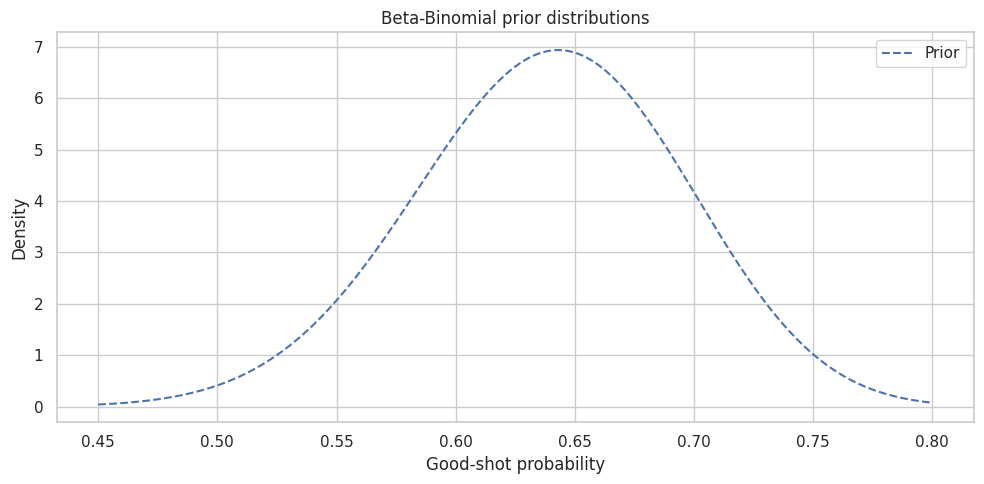

In [7]:
# Prior based on the team's overall success rate
p_global = df['good_shot'].mean()
prior_strength = 70
alpha_prior = p_global * prior_strength
beta_prior = (1 - p_global) * prior_strength

print(f"Prior: Beta({alpha_prior:.2f}, {beta_prior:.2f})")

x = np.linspace(0.45, 0.80, 1000)
plt.figure(figsize=(10, 5))
plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), '--', label='Prior')
plt.xlabel('Good-shot probability')
plt.ylabel('Density')
plt.title('Beta-Binomial prior distributions')
plt.legend()
plt.tight_layout()
plt.show()


### Posterior distribution

Since our priors are of the form $\pi \sim \operatorname{Beta}(\alpha,\beta)$ and the data follows a Binomial distribution $Y \sim \operatorname{Binomial}(n,\pi)$, we can obtain the posterior distributions analytically. This is done by adding the number of successes ($Y$) to $\alpha$ and the number of failures ($n - Y$) to $\beta$:

$$
\pi \mid Y \sim \operatorname{Beta}(\alpha + Y, \beta + n - Y)
$$

In the next cell, we visualize how the team's global prior is updated with the specific data from each case:

Mirotić ON posterior:  Beta(1461.73, 740.27)
Mirotić OFF posterior: Beta(954.73, 625.27)


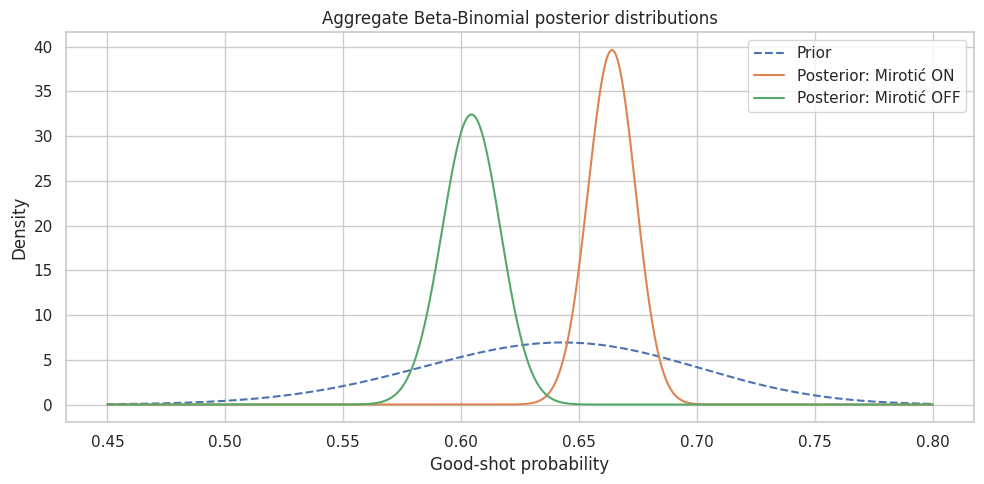

In [8]:
n_M = len(df_mirotic)
Y_M = int(df_mirotic['good_shot'].sum())
n_N = len(df_no_mirotic)
Y_N = int(df_no_mirotic['good_shot'].sum())

alpha_post_M = alpha_prior + Y_M
beta_post_M = beta_prior + (n_M - Y_M)
alpha_post_N = alpha_prior + Y_N
beta_post_N = beta_prior + (n_N - Y_N)

print(f"Mirotić ON posterior:  Beta({alpha_post_M:.2f}, {beta_post_M:.2f})")
print(f"Mirotić OFF posterior: Beta({alpha_post_N:.2f}, {beta_post_N:.2f})")

x = np.linspace(0.45, 0.80, 1000)
plt.figure(figsize=(10, 5))
plt.plot(x, beta.pdf(x, alpha_prior, beta_prior), '--', label='Prior')
plt.plot(x, beta.pdf(x, alpha_post_M, beta_post_M), label='Posterior: Mirotić ON')
plt.plot(x, beta.pdf(x, alpha_post_N, beta_post_N), label='Posterior: Mirotić OFF')
plt.xlabel('Good-shot probability')
plt.ylabel('Density')
plt.title('Aggregate Beta-Binomial posterior distributions')
plt.legend()
plt.tight_layout()
plt.show()


Now, we can see the **posterior mean**, the **posterior standard deviation** and the **middle 95% posterior creadible interval** for each case:

In [9]:
posteriors = {
    'Mirotić ON': (alpha_post_M, beta_post_M),
    'Mirotić OFF': (alpha_post_N, beta_post_N)
}

rows = []
for name, (a, b) in posteriors.items():
    mean, var = beta.stats(a, b, moments='mv')
    rows.append({
        'Context': name,
        'Posterior mean': mean,
        'Posterior std': np.sqrt(var),
        '95% credible interval lower': beta.ppf(0.025, a, b),
        '95% credible interval upper': beta.ppf(0.975, a, b)
    })

pd.DataFrame(rows)


,Context,Posterior mean,Posterior std,95% credible interval lower,95% credible interval upper
0,Mirotić ON,0.663817,0.010065,0.643952,0.683401
1,Mirotić OFF,0.604257,0.012298,0.580030,0.628233


We can see that we have around a 6% more chance to end the play with a good shot if we have Mirotic on the court. Moreover, we can see that there is no intersection between the credible intervals, so we can be highly confident that the team is better when Mirotic is playing.

### Numerical probability

To determine the probability that the team is more efficient with Mirotic on court, we perform a Monte Carlo simulation. We draw 100,000 random samples from both posterior distributions. Then, we calculate the proportion of samples where $\pi_M > \pi_N$.

P(Mirotić ON > Mirotić OFF): 99.9910%
Mean difference: 5.9548%


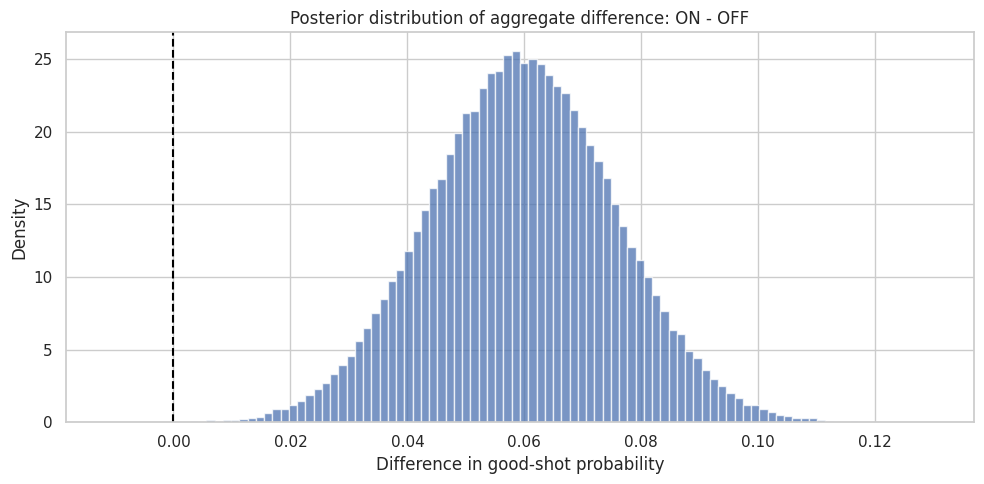

In [10]:
n_sims = 100_000

# We generate samples from the posterior distributions
samples_M = np.random.beta(alpha_post_M, beta_post_M, n_sims)
samples_N = np.random.beta(alpha_post_N, beta_post_N, n_sims)

# We calculate the probability that having Mirotic on the court improves the efficiency compared to not having him
prob_M_better = np.mean(samples_M > samples_N)

print(f"P(Mirotić ON > Mirotić OFF): {prob_M_better:.4%}")
print(f"Mean difference: {samples_M.mean() - samples_N.mean():.4%}")

plt.figure(figsize=(10, 5))
plt.hist(samples_M - samples_N, bins=100, density=True, alpha=0.75)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Difference in good-shot probability')
plt.ylabel('Density')
plt.title('Posterior distribution of aggregate difference: ON - OFF')
plt.tight_layout()
plt.show()

According to this Monte-Carlo simulation, we can be 99.9910% sure that when we have Mirotic on court, we have more probability of taking a good shot at the end of a play.

## 4. Non-hierarchical baseline: Logistic Regressor by scenario

In the previous section we have seen that, overall, we can be almost 100% sure that the presence of Mirotić on court improves the performance of the team. However, some people may still argue that it does not happen the same in key moments or matches. That is why, we continue with a Logistic Regressor model.

This method will allow us to analyze the importance of the Mirotić presence on court for each one of the scenarios we defined in the first section. So, the question we will try to answer in this section is:

> For each scenario, does Mirotić improve the team probability of ending the play with a good shot?

Mathematically, the model has the following form:
$$\text{logit}(p_i) = \alpha_j + \beta_j \cdot \text{Mirotić}_i$$

where:
- $p_i$ is the probability that the play $i$ ends with a good shot.
- $\text{logit}(p_i)$ is the log-odds transformation of that probability, which allows us to model a binary outcome using a linear expression.
- $j$ represents the scenario to which play $i$ belongs. In our case, each scenario is defined by the combination of `court` and `clutch`.
- $\alpha_j$ is the baseline log-odds of ending the play with a good shot in scenario $j$, when Mirotić is not on the court.
- $\beta_j$ is the effect of Mirotić in scenario $j$. If $\beta_j > 0$, then Mirotić increases the probability of ending the play with a good shot in that scenario; if $\beta_j < 0$, the estimated effect is negative.
- $\text{Mirotić}_i$ is an indicator variable equal to 1 if Mirotić is on the court during play $i$, and 0 otherwise.

### Prior choice
Since this logistic regression model works on the log-odds scale, we need to define priors for the scenario-specific intercepts and Mirotić effects on that scale.

From the exploratory analysis, the overall team good-shot rate was approximately:

$$
p \approx 0.639
$$

Transforming this probability to the log-odds scale gives:

$$
\operatorname{logit}(0.639)
=
\log\left(
\frac{0.639}{1 - 0.639}
\right)
\approx 0.57
$$

Therefore, we center the prior for the scenario-specific intercepts around 0.57:

$$
\alpha_j \sim \mathcal{N}(0.57, 1)
$$

This means that, before observing the scenario-specific data, we expect the baseline probability of generating a good shot to be close to the overall team average. However, the standard deviation of 1 is wide enough to allow substantial variation between scenarios.

For Mirotić's effect, we use a weakly informative prior centered at zero:

$$
\beta_j \sim \mathcal{N}(0, 0.5)
$$

This prior reflects the idea that, before looking at the scenario-specific evidence, Mirotić could have either a positive or negative effect. Centering the prior at zero also avoids forcing the model to assume that Mirotić helps in every scenario. The standard deviation of 0.5 allows for moderate effects on the log-odds scale while still regularizing extreme estimates, especially in scenarios with fewer observations.

Therefore, the flat logistic model estimates each scenario independently:

$$
\text{logit}(p_i) = \alpha_j + \beta_j \cdot \text{Mirotić}_i
$$

with:

$$
\alpha_j \sim \mathcal{N}(0.57, 1)
$$

$$
\beta_j \sim \mathcal{N}(0, 0.5)
$$

In [11]:
with pm.Model(coords={"groups": group_names}) as flat_logistic_model:
    alpha_flat = pm.Normal("alpha_flat", mu=0.57, sigma=1.0, dims="groups")
    beta_flat = pm.Normal("beta_flat", mu=0.0, sigma=0.5, dims="groups")

    logit_theta_flat = (
        alpha_flat[group_mapping]
        + beta_flat[group_mapping] * has_mirotic_idx
    )

    y_flat = pm.Bernoulli(
        "y_obs",
        logit_p=logit_theta_flat,
        observed=y_obs
    )

    idata_flat = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        target_accept=0.95
    )

    pm.compute_log_likelihood(idata_flat)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha_flat, beta_flat]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 41 seconds.


Output()

Now, let's check a summary of the resulting model we have obtained:

In [12]:
az.summary(
    idata_flat,
    var_names=['alpha_flat', 'beta_flat'],
    hdi_prob=0.94
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha_flat[Local_0],0.444,0.073,0.309,0.587,0.001,0.001,6992.0,5616.0,1.0
alpha_flat[Local_1],0.514,0.291,-0.049,1.051,0.004,0.003,6375.0,4870.0,1.0
alpha_flat[Neutral_0],0.619,0.287,0.095,1.167,0.003,0.003,7368.0,6104.0,1.0
alpha_flat[Neutral_1],0.643,0.356,-0.023,1.299,0.005,0.004,6184.0,5661.0,1.0
alpha_flat[Visitant_0],0.430,0.080,0.284,0.583,0.001,0.001,6484.0,5569.0,1.0
alpha_flat[Visitant_1],-0.057,0.320,-0.648,0.542,0.004,0.004,6763.0,5164.0,1.0
beta_flat[Local_0],0.335,0.102,0.144,0.524,0.001,0.001,6689.0,5895.0,1.0
beta_flat[Local_1],0.515,0.312,-0.066,1.101,0.004,0.003,6335.0,5770.0,1.0
beta_flat[Neutral_0],0.383,0.337,-0.243,1.019,0.004,0.004,7333.0,6078.0,1.0
beta_flat[Neutral_1],0.035,0.360,-0.674,0.671,0.004,0.004,6692.0,6079.0,1.0


The convergence diagnostics of the flat logistic model are satisfactory, with all $\hat{R}$ values equal to 1.0 and high effective sample sizes. Therefore, the posterior estimates appear to be stable.

Regarding Mirotić's effect, all scenario-specific posterior means for $\beta_j$ are positive. This suggests that the model estimates a positive average effect in every scenario. However, the strength of the evidence differs across contexts.

The clearest positive effect appears in `Local_0`, where the 94% HDI is entirely above zero. In contrast, the effects in `Local_1`, `Neutral_0`, `Visitant_0`, and `Visitant_1` are positive on average but uncertain, since their HDIs include zero. Finally, `Neutral_1` shows an effect very close to zero, suggesting little evidence of improvement in that scenario.

To make this interpretation more intuitive, in the next step we compute $P(\beta_j > 0)$, which directly represents the posterior probability that Mirotić improves the probability of generating a good shot in each scenario.


In [13]:
# Probability that Mirotić improves good-shot probability in each scenario
beta_flat_samples = idata_flat.posterior['beta_flat'].stack(sample=("chain", "draw"))
prob_beta_flat_pos = (beta_flat_samples > 0).mean(dim='sample').values

flat_effect_summary = pd.DataFrame({
    'Scenario': group_names,
    'P(beta_flat > 0)': prob_beta_flat_pos,
    'Mean beta_flat': beta_flat_samples.mean(dim='sample').values
})
flat_effect_summary

,Scenario,P(beta_flat > 0),Mean beta_flat
0,Local_0,0.999250,0.335008
1,Local_1,0.952250,0.515441
2,Neutral_0,0.872875,0.382955
3,Neutral_1,0.540000,0.034746
4,Visitant_0,0.874500,0.123008
5,Visitant_1,0.670375,0.143072


In the next cell we can see a plot comparing the distributions for each case:

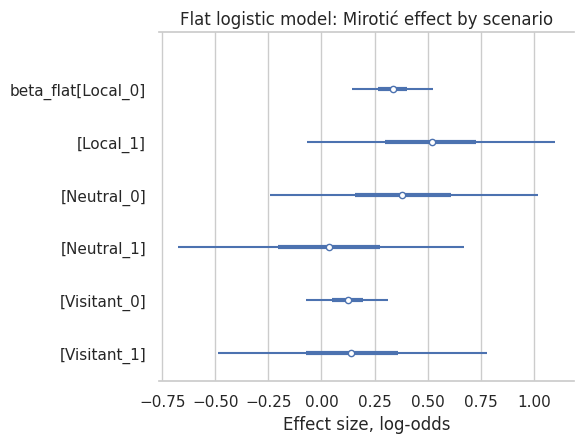

In [14]:
az.plot_forest(
    idata_flat,
    var_names=['beta_flat'],
    combined=True,
    hdi_prob=0.94
)
plt.title('Flat logistic model: Mirotić effect by scenario')
plt.xlabel('Effect size, log-odds')
plt.tight_layout()
plt.show()

Finally, we recap the results and show them in the following table:

In [15]:
# Posterior samples
alpha_flat_samples = idata_flat.posterior["alpha_flat"].values  # chains, draws, groups
beta_flat_samples = idata_flat.posterior["beta_flat"].values    # chains, draws, groups

# Convert from log-odds to probabilities
p_off_flat = sp.expit(alpha_flat_samples)
p_on_flat = sp.expit(alpha_flat_samples + beta_flat_samples)

# Difference ON - OFF
diff_flat = p_on_flat - p_off_flat

rows = []

for idx, scenario in enumerate(group_names):
    off_samples = p_off_flat[:, :, idx].flatten()
    on_samples = p_on_flat[:, :, idx].flatten()
    diff_samples = diff_flat[:, :, idx].flatten()

    rows.append({
        "Scenario": scenario,
        "P_OFF_mean": off_samples.mean(),
        "P_ON_mean": on_samples.mean(),
        "Difference_mean": diff_samples.mean(),
        "P_ON_greater_OFF": (diff_samples > 0).mean(),
        "Diff_3%": np.percentile(diff_samples, 3),
        "Diff_97%": np.percentile(diff_samples, 97)
    })

flat_probability_summary = pd.DataFrame(rows)
flat_probability_summary

,Scenario,P_OFF_mean,P_ON_mean,Difference_mean,P_ON_greater_OFF,Diff_3%,Diff_97%
0,Local_0,0.609016,0.685208,0.076192,0.999250,0.032670,0.118954
1,Local_1,0.623422,0.735575,0.112153,0.952250,-0.015590,0.245707
2,Neutral_0,0.647220,0.727842,0.080621,0.872875,-0.050397,0.215424
3,Neutral_1,0.651105,0.661400,0.010295,0.540000,-0.133931,0.164648
4,Visitant_0,0.605825,0.634791,0.028966,0.874500,-0.016898,0.075321
5,Visitant_1,0.486157,0.521347,0.035190,0.670375,-0.120458,0.189426


As we have seen in this section, this flat Logistic Regressor gives us strong evidence that in most of the cases we have more probability of taking a good shot when Mirotić is on court. However, we have found a considerable uncertainty in the cases `Neutral_1` and `Visitant_1` specially.

Will the Hierarchical Logistic Regressor be able to clarify those scenarios?

## 5. Hierarchical Model: Hierarchical Logistic Regressor with partial pooling

The hierarchical model estimates scenario-specific baseline efficiencies and Mirotić effects, but it connects them through group-level distributions.

This allows **partial pooling**: noisy scenario estimates are regularized toward the global mean, while still allowing heterogeneous effects across scenarios.

\[
	ext{logit}(p_i) = lpha_{j[i]} + eta_{j[i]} \cdot 	ext{Mirotic}_i
\]

with:

\[
lpha_j = \mu_lpha + \sigma_lpha z_{lpha,j}
\]

\[
eta_j = \mu_eta + \sigma_eta z_{eta,j}
\]


In [15]:
with pm.Model(coords={"groups": group_names}) as hierarchical_model:
    # Group-specific baseline intercepts
    mu_a = pm.Normal('mu_a', mu=0.57, sigma=1.0)
    sigma_a = pm.HalfNormal('sigma_a', sigma=0.5)
    a_offset = pm.Normal('a_offset', mu=0.0, sigma=1.0, dims="groups")
    alpha = pm.Deterministic('alpha', mu_a + sigma_a * a_offset, dims="groups")

    # Group-specific Mirotić effects
    mu_b = pm.Normal('mu_b', mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal('sigma_b', sigma=0.3)
    b_offset = pm.Normal('b_offset', mu=0.0, sigma=1.0, dims="groups")
    beta_mirotic = pm.Deterministic('beta_mirotic', mu_b + sigma_b * b_offset, dims="groups")

    logit_theta = alpha[group_mapping] + beta_mirotic[group_mapping] * has_mirotic_idx

    y_likelihood = pm.Bernoulli(
        'y_obs',
        logit_p=logit_theta,
        observed=y_obs
    )

    idata_hierarchical = pm.sample(
        draws=2000,
        tune=1000,
        chains=4,
        random_seed=RANDOM_SEED,
        return_inferencedata=True,
        target_accept=0.99
    )

    pm.compute_log_likelihood(idata_hierarchical)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_a, sigma_a, a_offset, mu_b, sigma_b, b_offset]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 152 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


Output()

In [16]:
az.summary(
    idata_hierarchical,
    var_names=['mu_a', 'sigma_a', 'mu_b', 'sigma_b', 'alpha', 'beta_mirotic'],
    hdi_prob=0.94
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,0.406,0.128,0.140,0.625,0.002,0.004,3104.0,2677.0,1.0
sigma_a,0.184,0.152,0.000,0.453,0.004,0.003,1640.0,3414.0,1.0
mu_b,0.285,0.133,0.044,0.549,0.002,0.002,3577.0,4563.0,1.0
sigma_b,0.221,0.134,0.001,0.446,0.003,0.001,2189.0,2535.0,1.0
alpha[Local_0],0.438,0.067,0.314,0.566,0.001,0.001,8438.0,7403.0,1.0
alpha[Local_1],0.483,0.164,0.199,0.830,0.003,0.002,3526.0,5027.0,1.0
alpha[Neutral_0],0.475,0.168,0.172,0.831,0.002,0.002,5253.0,5947.0,1.0
alpha[Neutral_1],0.421,0.167,0.096,0.758,0.002,0.002,7482.0,6096.0,1.0
alpha[Visitant_0],0.402,0.071,0.267,0.536,0.001,0.001,7631.0,6888.0,1.0
alpha[Visitant_1],0.206,0.235,-0.254,0.546,0.005,0.002,2131.0,5459.0,1.0


In [17]:
posterior = idata_hierarchical.posterior
beta_hier_samples = posterior['beta_mirotic'].stack(sample=("chain", "draw"))
mu_b_samples = posterior['mu_b'].stack(sample=("chain", "draw"))

prob_beta_hier_pos = (beta_hier_samples > 0).mean(dim='sample').values
prob_global_hier_pos = float((mu_b_samples > 0).mean(dim='sample'))

hier_effect_summary = pd.DataFrame({
    'Scenario': group_names,
    'P(beta_mirotic > 0)': prob_beta_hier_pos,
    'Mean beta_mirotic': beta_hier_samples.mean(dim='sample').values
})

print(f"Global P(mu_b > 0): {prob_global_hier_pos:.4%}")
hier_effect_summary

Global P(mu_b > 0): 98.1750%


,Scenario,P(beta_mirotic > 0),Mean beta_mirotic
0,Local_0,1.000000,0.337859
1,Local_1,0.995500,0.466403
2,Neutral_0,0.984000,0.415219
3,Neutral_1,0.926500,0.273773
4,Visitant_0,0.959875,0.176728
5,Visitant_1,0.663125,0.087783


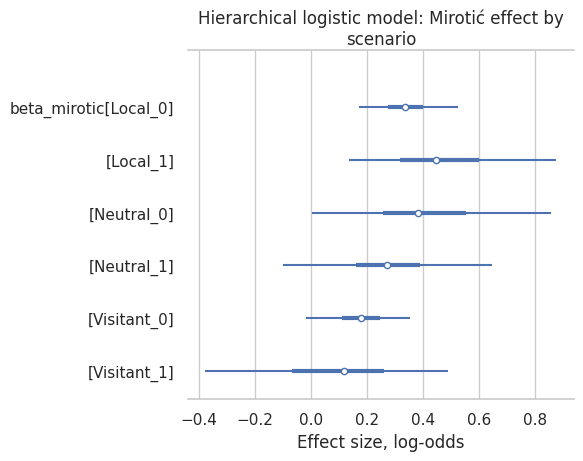

In [18]:
az.plot_forest(
    idata_hierarchical,
    var_names=['beta_mirotic'],
    combined=True,
    hdi_prob=0.94
)
plt.title('Hierarchical logistic model: Mirotić effect by scenario')
plt.xlabel('Effect size, log-odds')
plt.tight_layout()
plt.show()

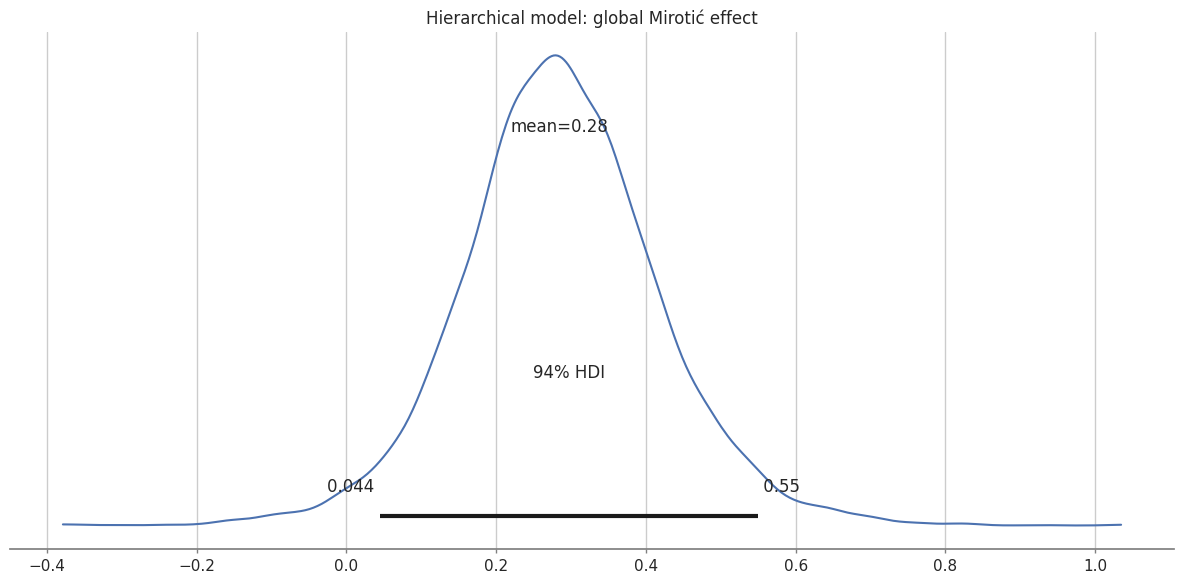

In [19]:
az.plot_posterior(
    idata_hierarchical,
    var_names=['mu_b'],
    hdi_prob=0.94
)
plt.title('Hierarchical model: global Mirotić effect')
plt.tight_layout()
plt.show()

In [21]:
# Posterior samples
alpha_hier_samples = idata_hierarchical.posterior["alpha"].values
beta_hier_samples = idata_hierarchical.posterior["beta_mirotic"].values

# Convert from log-odds to probabilities
p_off_hier = sp.expit(alpha_hier_samples)
p_on_hier = sp.expit(alpha_hier_samples + beta_hier_samples)

# Difference ON - OFF
diff_hier = p_on_hier - p_off_hier

rows = []

for idx, scenario in enumerate(group_names):
    off_samples = p_off_hier[:, :, idx].flatten()
    on_samples = p_on_hier[:, :, idx].flatten()
    diff_samples = diff_hier[:, :, idx].flatten()

    rows.append({
        "Scenario": scenario,
        "P_OFF_mean": off_samples.mean(),
        "P_ON_mean": on_samples.mean(),
        "Difference_mean": diff_samples.mean(),
        "P_ON_greater_OFF": (diff_samples > 0).mean(),
        "Diff_3%": np.percentile(diff_samples, 3),
        "Diff_97%": np.percentile(diff_samples, 97)
    })

hier_probability_summary = pd.DataFrame(rows)
hier_probability_summary

,Scenario,P_OFF_mean,P_ON_mean,Difference_mean,P_ON_greater_OFF,Diff_3%,Diff_97%
0,Local_0,0.607571,0.684505,0.076934,1.000000,0.037378,0.118012
1,Local_1,0.617784,0.719871,0.102087,0.995500,0.030259,0.189473
2,Neutral_0,0.615826,0.706715,0.090888,0.984000,0.011048,0.193932
3,Neutral_1,0.603047,0.665651,0.062604,0.926500,-0.023956,0.144855
4,Visitant_0,0.598933,0.640511,0.041579,0.959875,-0.003295,0.084573
5,Visitant_1,0.550891,0.572294,0.021403,0.663125,-0.096776,0.116745


## 6. Flat vs Hierarchical: Effect Comparison

This table helps interpret how partial pooling changes the scenario-specific Mirotić estimates.


In [ ]:
comparison_effects = flat_effect_summary.merge(
    hier_effect_summary,
    on='Scenario',
    how='inner'
)
comparison_effects


In [ ]:
flat_means = comparison_effects['Mean beta_flat'].values
hier_means = comparison_effects['Mean beta_mirotic'].values

plt.figure(figsize=(8, 6))
plt.scatter(flat_means, hier_means, s=100)
for i, scenario in enumerate(comparison_effects['Scenario']):
    plt.text(flat_means[i] + 0.005, hier_means[i] + 0.005, scenario)

min_val = min(flat_means.min(), hier_means.min()) - 0.05
max_val = max(flat_means.max(), hier_means.max()) + 0.05
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray')
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Flat logistic beta estimate')
plt.ylabel('Hierarchical beta estimate')
plt.title('Scenario-specific Mirotić effects: flat vs hierarchical')
plt.tight_layout()
plt.show()


## 7. Model Comparison: WAIC and LOO-CV

We compare only the two logistic models because they are directly comparable:

- same response variable;
- same observation level;
- same Bernoulli likelihood;
- same scenario information.

The Beta-Binomial aggregate model is not included in this comparison because it uses aggregated data and a different likelihood structure.


In [ ]:
comparison_dict = {
    "Flat logistic model (no pooling)": idata_flat,
    "Hierarchical logistic model (partial pooling)": idata_hierarchical,
}

print("=== WAIC MODEL COMPARISON ===")
waic_comparison = az.compare(comparison_dict, ic="waic")
display(waic_comparison)

print("=== LOO-CV MODEL COMPARISON ===")
loo_comparison = az.compare(comparison_dict, ic="loo")
display(loo_comparison)

In [ ]:
az.plot_compare(loo_comparison)
plt.title('Model comparison using LOO-CV')
plt.tight_layout()
plt.show()


## 8. Suggested Interpretation Template

Use this section after running the notebook and checking the numerical results.

1. **Aggregate signal.** The Beta-Binomial analysis suggests whether the raw good-shot rate is higher with Mirotić on court.
2. **Why logistic models are needed.** The aggregate result ignores context, so we move to play-level logistic models with `court × clutch` scenarios.
3. **Flat logistic baseline.** The non-hierarchical baseline estimates independent scenario-specific Mirotić effects, but does not share information across scenarios.
4. **Hierarchical model.** The hierarchical model allows Mirotić's effect to vary by scenario while stabilizing estimates through partial pooling.
5. **Model comparison.** If LOO/WAIC favors the hierarchical model, the data support partial pooling. If the difference is small, the hierarchical model may still be preferable for interpretability and regularization, but the predictive advantage should be described as modest.
